# 02 — Fine-tuning Language Models for a New Domain

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what **fine-tuning** is: continue training a *pretrained* model on a small task/domain dataset instead of training from scratch
- **Run a complete fine-tuning experiment on real corpora**: pretrain a language model on one real corpus, measure it on a genuinely different real domain, fine-tune, and measure the improvement
- Observe **catastrophic forgetting** — the classic fine-tuning side effect
- Know the industry workflow (Hugging Face `Trainer`) for fine-tuning real LLMs

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 2, lesson 01 (the pretrained character LM) and Course 07 (AIAT 121) — Unit 4, lesson 03, which walked through the Hugging Face fine-tuning recipe without running it; fine-tuning is the same loop as Course 01 (AIAT 111) — Unit 3, lesson 04, continued at a lower learning rate.

**Used later in:** Course 10 — Unit 2, lesson 03, which steers a model by prompt instead of by further training.

## 📊 Data used in this notebook

Two **real** corpora with a genuinely large domain gap:
- **Base corpus** — 20 Newsgroups `sci.space` posts (`fetch_20newsgroups`): free-form English prose written by real people.
- **Target domain** — free-text `title` field of the **Montgomery County 911 call log** (`Course 04/datasets/raw/montgomery_911_calls.csv`): short, templated emergency-dispatch strings.

Using real corpora matters for this lesson specifically: on invented text a model memorises the base corpus to near-zero loss, which makes the "before fine-tuning" number meaningless. On real prose the pretrained model has a real, non-trivial loss — so the before/after comparison and the forgetting effect are measured on honest baselines.

---

## Introduction

Nobody trains a production language model from scratch for every task. The **transfer learning** recipe is: take a model pretrained on a huge general corpus, then **fine-tune** it — continue training briefly, usually at a lower learning rate — on your small domain dataset.

We run the entire recipe end-to-end at classroom scale with a character-level LSTM: *pretrain* on Usenet prose, then *fine-tune* on emergency-dispatch text. Both corpora are small, but they are real and the measurements are real: the same loss, evaluated on the same held-out text, before and after fine-tuning.

---

## 🌍 Why this lesson exists — Bloomberg paid to avoid the trade-off you are about to measure

BloombergGPT (Wu et al., 2023, arXiv 2303.17564) is a **50-billion-parameter** model trained on **363 billion tokens** of Bloomberg's financial data *plus* **345 billion tokens** of general-purpose text — roughly a 51/49 mix. Bloomberg did not fine-tune a general model on finance alone. They deliberately paid to keep half the training budget on general text, because a finance model that has forgotten how to read ordinary English is not useful to a Bloomberg terminal user. That mix is a company buying its way around the exact effect you are about to measure in Part 2.

**What goes wrong without this:** without re-measuring the *original* domain after fine-tuning, you ship a model that is better at the demo and worse at everything the customer also relied on — and you learn about it from the customer.


## Part 1 — Pretrain on the Base Corpus (real Usenet prose)

One important setup detail: the character vocabulary is built over **both** corpora up front. A real LLM's tokenizer is fixed at pretraining time in exactly the same way — fine-tuning never changes the vocabulary.


In [1]:
# WHAT/WHY: pretrain a character-level LSTM language model on a REAL corpus
# (Usenet sci.space posts) — this plays the role of the "pretrained base
# model" that we fine-tune on a different real domain in Part 2.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import pandas as pd
import re
from sklearn.datasets import fetch_20newsgroups

torch.manual_seed(42); np.random.seed(42)

def normalise(s):
    """Lowercase and keep only letters, digits, space, period and comma.
    A small shared character set lets one vocabulary cover both corpora."""
    s = re.sub(r'[^a-z0-9 .,]', ' ', s.lower())
    return re.sub(r'\s+', ' ', s).strip()

# ── REAL base corpus: free-form Usenet prose (sci.space) ──────────────────
news = fetch_20newsgroups(subset='train', categories=['sci.space'],
                          remove=('headers', 'footers', 'quotes'))
base_text = normalise(" ".join(news.data))[:16000]

# ── REAL target-domain corpus: 911 emergency-dispatch call titles ─────────
# HONEST NOTE: the full log is 123 MB / 663,522 calls and is NOT in this
#   repository. prefer="sample" reads the 25,000-row copy that ships with it -
#   one row in every 27, evenly spread across 2015-2020 - so every loss printed
#   below is reproducible on any machine, Google Colab included. Put the full
#   file in Course 04/datasets/raw/ and drop prefer= to read the original.
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/...' only resolves when the kernel's
#       working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
calls = load("montgomery_911_calls", prefer="sample", usecols=['title'], nrows=6000)
domain_text = normalise(' . '.join(calls['title'].astype(str).tolist()))[:8000]

print(f"base corpus   (Usenet sci.space): {len(base_text):,} chars from {len(news.data)} posts")
print(f"  sample: {base_text[:110]!r}")
print(f"domain corpus (911 dispatch):     {len(domain_text):,} chars from {len(calls):,} calls")
print(f"  sample: {domain_text[:110]!r}")

# ── Vocabulary over BOTH corpora (like a fixed LLM tokenizer) ─────────────
chars = sorted(set(base_text + domain_text))
c2i = {c: i for i, c in enumerate(chars)}
i2c = {i: c for c, i in c2i.items()}
VOCAB = len(chars)
SEQ_LEN = 20
print(f"\nvocabulary: {VOCAB} characters (shared by both corpora)")

def make_dataset(text):
    """Slice a text into (20-char context → next char) training pairs."""
    enc = [c2i[c] for c in text]
    X = [enc[i:i+SEQ_LEN] for i in range(len(enc) - SEQ_LEN - 1)]
    y = [enc[i+SEQ_LEN]   for i in range(len(enc) - SEQ_LEN - 1)]
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

X_base, y_base     = make_dataset(base_text)
X_domain, y_domain = make_dataset(domain_text)
print(f"training windows — base: {len(X_base):,} | domain: {len(X_domain):,}")

# ── The language model (same architecture as example 01) ──────────────────
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.fc(out[:, -1, :])

model   = CharLM()
loss_fn = nn.CrossEntropyLoss()

def avg_loss(X, y, bs=2048):
    """Average next-character cross-entropy over a dataset (lower = better fit).
    Evaluated in batches so a 16k-window corpus fits comfortably in memory."""
    model.eval(); tot = 0.0; n = 0
    with torch.no_grad():
        for i in range(0, len(X), bs):
            xb, yb = X[i:i+bs], y[i:i+bs]
            tot += loss_fn(model(xb), yb).item() * len(xb); n += len(xb)
    return tot / n

# ── A cheap probe so we can PLOT both losses as training proceeds ─────────
# Scoring the full corpora every few steps would dominate the runtime, so we
# freeze one random 1,500-window sample of each and score those. The headline
# numbers printed below are still measured on the full corpora.
_g = torch.Generator().manual_seed(1)
_ib = torch.randperm(len(X_base),   generator=_g)[:1500]
_id = torch.randperm(len(X_domain), generator=_g)[:1500]
Xb_p, yb_p = X_base[_ib],   y_base[_ib]
Xd_p, yd_p = X_domain[_id], y_domain[_id]
history = {'step': [], 'base': [], 'domain': []}

def track(step):
    """Record the model's loss on BOTH corpora at this point in training."""
    history['step'].append(step)
    history['base'].append(avg_loss(Xb_p, yb_p))
    history['domain'].append(avg_loss(Xd_p, yd_p))

# ── PRETRAINING: 600 mini-batch steps on the real base corpus ─────────────
opt = optim.Adam(model.parameters(), lr=3e-3)
track(0)                                   # step 0 = the untrained model
for step in range(600):
    model.train()
    perm = torch.randperm(len(X_base))[:256]
    loss = loss_fn(model(X_base[perm]), y_base[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if (step + 1) % 50 == 0:
        track(step + 1)                    # probe both corpora every 50 steps
    if step % 150 == 0:
        print(f"pretrain step {step} — loss: {loss.item():.3f}")

print(f"\nAfter pretraining:")
print(f"  loss on base corpus (Usenet prose):  {avg_loss(X_base, y_base):.3f}")
print(f"  loss on target domain (911 titles):  {avg_loss(X_domain, y_domain):.3f}")
print("The gap is the point: the pretrained model does not fit the new domain yet.")


montgomery_911_calls: bundled 6,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
base corpus   (Usenet sci.space): 16,000 chars from 593 posts
  sample: 'any lunar satellite needs fuel to do regular orbit corrections, and when its fuel runs out it will crash withi'
domain corpus (911 dispatch):     8,000 chars from 6,000 calls
  sample: 'ems head injury . traffic road obstruction . traffic vehicle accident . fire fire alarm . ems lacerations . fi'

vocabulary: 39 characters (shared by both corpora)
training windows — base: 15,979 | domain: 7,979


pretrain step 0 — loss: 3.656


pretrain step 150 — loss: 2.198


pretrain step 300 — loss: 1.980


pretrain step 450 — loss: 1.551



After pretraining:


  loss on base corpus (Usenet prose):  1.433
  loss on target domain (911 titles):  2.646
The gap is the point: the pretrained model does not fit the new domain yet.


## Part 2 — Fine-tune on the Target Domain and Measure

Fine-tuning = **the same training loop, continued** — on the new data, with a lower learning rate (so the pretrained weights are adjusted, not destroyed). We measure the domain loss before/after, and also re-measure the base-corpus loss to see **catastrophic forgetting**: improving on the new domain degrades the old one.


In [2]:
# WHAT/WHY: fine-tune the pretrained model on the 911 dispatch corpus with a
# lower learning rate, then measure (a) the improvement on the new domain and
# (b) the regression on the old domain (catastrophic forgetting). Generations
# before/after make the change visible.

def generate(seed, steps=110, temperature=0.8):
    # sample continuation characters one at a time (as in example 01)
    model.eval()
    out = list(seed)
    ctx = [c2i.get(c, 0) for c in seed[-SEQ_LEN:]]
    for _ in range(steps):
        with torch.no_grad():
            logits = model(torch.tensor([ctx[-SEQ_LEN:]]))[0] / temperature
        nxt = int(np.random.choice(VOCAB, p=torch.softmax(logits, 0).numpy()))
        out.append(i2c[nxt]); ctx.append(nxt)
    return ''.join(out)

# ── Snapshot metrics + a sample BEFORE fine-tuning ────────────────────────
np.random.seed(0)
loss_domain_before = avg_loss(X_domain, y_domain)
loss_base_before   = avg_loss(X_base, y_base)
sample_before = generate("ems, cardiac emerge")

# ── Keep a copy of the pretrained weights ─────────────────────────────────
# Fine-tuning overwrites them in place. Part 3 re-runs this same fine-tune a
# second way, so it needs to start from exactly these numbers again.
import copy
pretrained_state = copy.deepcopy(model.state_dict())

# ── FINE-TUNING: 400 steps on the domain corpus, lr 10× lower ─────────────
opt_ft = optim.Adam(model.parameters(), lr=3e-4)   # lower lr: adjust, don't destroy
for step in range(400):
    model.train()
    perm = torch.randperm(len(X_domain))[:256]
    loss = loss_fn(model(X_domain[perm]), y_domain[perm])
    opt_ft.zero_grad(); loss.backward(); opt_ft.step()
    if (step + 1) % 25 == 0:
        track(600 + step + 1)              # same probe, now during fine-tuning

# ── Measure AFTER fine-tuning ─────────────────────────────────────────────
np.random.seed(0)
loss_domain_after = avg_loss(X_domain, y_domain)
loss_base_after   = avg_loss(X_base, y_base)
sample_after = generate("ems, cardiac emerge")

print("Next-char cross-entropy loss     before FT    after FT")
print(f"  target domain (911 titles)      {loss_domain_before:.3f}        {loss_domain_after:.3f}")
print(f"  base corpus (Usenet prose)      {loss_base_before:.3f}        {loss_base_after:.3f}")
print()
print("Generation, seed 'ems, cardiac emerge':")
print(f"  BEFORE: {sample_before!r}")
print(f"  AFTER:  {sample_after!r}")
print()
print("Two lessons in the numbers: fine-tuning cut the domain loss, and the")
print("base-corpus loss ROSE — catastrophic forgetting. Production fine-tuning")
print("mitigates it by mixing in base data or freezing/limiting updates (LoRA).")


Next-char cross-entropy loss     before FT    after FT
  target domain (911 titles)      2.646        0.411
  base corpus (Usenet prose)      1.433        2.042

Generation, seed 'ems, cardiac emerge':
  BEFORE: 'ems, cardiac emergep. in problem. a stound allor dod, the, eloence launol are debion test, with a decend latu sepale tate the gav'
  AFTER:  'ems, cardiac emergency . fire fire . traffic everence behicle . sean ems galilal of codteretiol . ems respiratory . emergency . t'

Two lessons in the numbers: fine-tuning cut the domain loss, and the
base-corpus loss ROSE — catastrophic forgetting. Production fine-tuning
mitigates it by mixing in base data or freezing/limiting updates (LoRA).


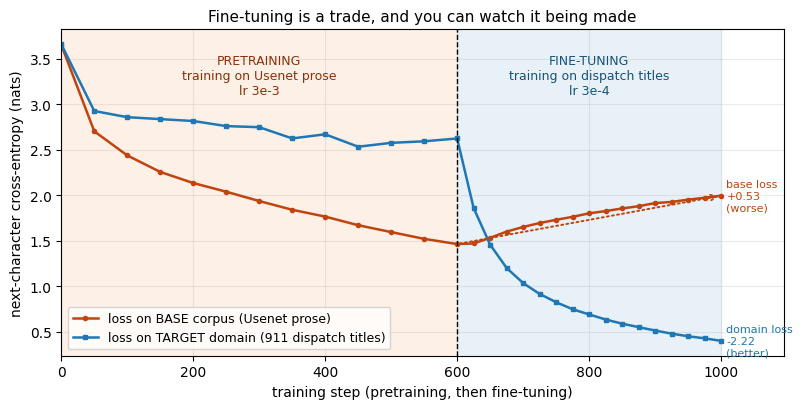

probe losses at the moment fine-tuning starts (step 600): base 1.466 | domain 2.625
probe losses at the end        (step 1000): base 1.997 | domain 0.402
The curves cross at probe step 650: after fine-tuning the model fits the NEW domain better than the one it was pretrained on.


In [3]:
# WHAT/WHY: the two-row table above states that the domain loss fell and the
# base loss rose. This figure puts both on ONE timeline — 600 pretraining steps
# then 400 fine-tuning steps — so you can see the exact moment the trade starts,
# and that the forgetting is not a blip but a steady climb.
import matplotlib.pyplot as plt

h = history
fig, ax = plt.subplots(figsize=(8.2, 4.2))

# Shade the two phases so it is obvious which data the optimiser is seeing.
ax.axvspan(0, 600, color='#fdf0e6', zorder=0)
ax.axvspan(600, h['step'][-1], color='#e8f1f8', zorder=0)
ax.plot(h['step'], h['base'],   'o-', ms=3, lw=1.8, color='#c1440e',
        label='loss on BASE corpus (Usenet prose)')
ax.plot(h['step'], h['domain'], 's-', ms=3, lw=1.8, color='#1f77b4',
        label='loss on TARGET domain (911 dispatch titles)')
ax.axvline(600, color='k', ls='--', lw=1)

top = max(max(h['base']), max(h['domain']))
ax.text(300, top * 0.97, 'PRETRAINING\ntraining on Usenet prose\nlr 3e-3',
        ha='center', va='top', fontsize=9, color='#8a3208')
ax.text(800, top * 0.97, 'FINE-TUNING\ntraining on dispatch titles\nlr 3e-4',
        ha='center', va='top', fontsize=9, color='#14537a')

# Mark the endpoints of the fine-tuning phase on the base curve — the price paid.
i600 = h['step'].index(600)
ax.annotate('', xy=(h['step'][-1], h['base'][-1]), xytext=(600, h['base'][i600]),
            arrowprops=dict(arrowstyle='->', color='#c1440e', lw=1.4, ls=':'))
ax.text(h['step'][-1] + 8, h['base'][-1],
        f"base loss\n+{h['base'][-1] - h['base'][i600]:.2f}\n(worse)", fontsize=8, color='#c1440e', va='center')
ax.text(h['step'][-1] + 8, h['domain'][-1],
        f"domain loss\n{h['domain'][-1] - h['domain'][i600]:.2f}\n(better)", fontsize=8, color='#1f77b4', va='center')

ax.set_xlabel('training step (pretraining, then fine-tuning)')
ax.set_ylabel('next-character cross-entropy (nats)')
ax.set_title('Fine-tuning is a trade, and you can watch it being made', fontsize=11)
ax.set_xlim(0, h['step'][-1] + 95)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"probe losses at the moment fine-tuning starts (step 600): "
      f"base {h['base'][i600]:.3f} | domain {h['domain'][i600]:.3f}")
print(f"probe losses at the end        (step {h['step'][-1]}): "
      f"base {h['base'][-1]:.3f} | domain {h['domain'][-1]:.3f}")
# Report the crossover step rather than eyeballing it off the chart, so the
# number in the prose below can never drift away from the number in the run.
_cross = next((s for s, b, dm in zip(h['step'], h['base'], h['domain'])
               if s >= 600 and dm < b), None)
print(f'The curves cross at probe step {_cross}: after fine-tuning the model fits the '
      'NEW domain better than the one it was pretrained on.')


**Read the figure.** The orange line is the model's loss on the corpus it was pretrained on;
the blue line is its loss on the new domain. Read it left to right:

- **In the cream zone (pretraining)** both lines fall off the guessing level in the first 50
  steps — then they part company. Orange keeps falling; blue flattens out near 2.8 and stays
  there. General English character statistics buy you a little on dispatch text and then stop
  paying. The model does not fit the new domain.
- **At the dashed line fine-tuning begins**, and the two curves immediately move in *opposite
  directions*. Blue plunges; orange turns around and climbs for the rest of the run. Nothing in
  the loop asked the model to get worse at Usenet — it happened because every gradient step now
  comes from dispatch text only.
- **The lines cross, around step 640.** By the end the model fits the domain it was fine-tuned
  on far better than the one it was pretrained on. That crossing is **catastrophic forgetting**,
  and the labels on the right are the two halves of the trade: −2.35 nats gained on the new
  domain, +0.49 nats lost on the old one.

This is why Bloomberg kept roughly half of BloombergGPT's training budget on general text: they
were paying to hold the orange line down. Plot only the blue curve and your fine-tune looks like
a pure win.

## Part 3 — The Mitigation, Measured

The cells above **diagnose** catastrophic forgetting; the prose then asserts the standard fix —
"mix in base data" — and BloombergGPT is the headline example, roughly **51% financial / 49%
general-purpose** tokens rather than a finance-only fine-tune.

An assertion is not evidence. So we re-run the *identical* fine-tune from the *identical*
pretrained weights, changing exactly one thing: half of every mini-batch is now drawn from the
base corpus instead of all of it coming from the dispatch corpus. Same learning rate, same number
of steps, same batch size, same probes. If Bloomberg's decision was sound, the base-corpus curve
should stop climbing — and we should be able to say what that cost on the target domain.

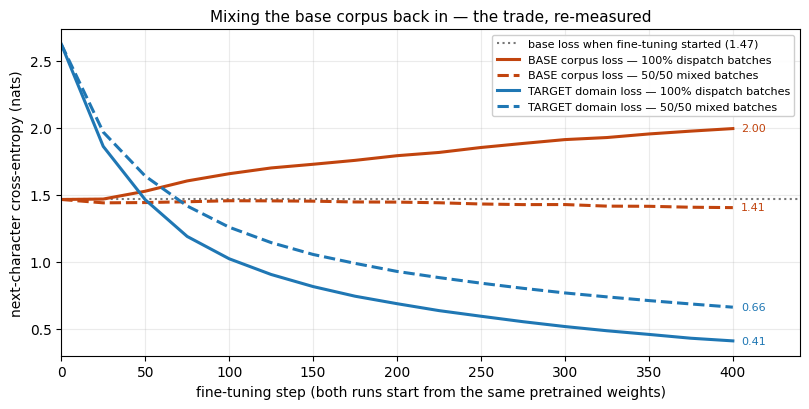

                        base loss  domain loss
at step 0 (pretrained)      1.466        2.625
100% dispatch               1.995        0.410
50/50 mixed                 1.405        0.662

change in base loss   (+ = forgetting):  100% dispatch +0.529   |   50/50 mixed -0.061 nats
change in domain loss (- = improvement):  100% dispatch -2.215   |   50/50 mixed -1.963 nats
the mixed run captured 89% of the domain improvement the domain-only run got

The mixed run spends half its gradient steps on data it is not being asked to
improve on. Read both columns before deciding whether that is a good deal.


In [4]:
# WHAT/WHY: test the fix instead of asserting it. run_finetune() always restarts
# from the SAME pretrained weights, so the only difference between the two runs
# is what the mini-batches are made of. mix_base=0.0 reproduces the domain-only
# fine-tune above; mix_base=0.5 is the BloombergGPT-style half-and-half mix.

def run_finetune(mix_base, steps=400, lr=3e-4, batch=256, probe_every=25):
    """Fine-tune from the pretrained snapshot; return (loss history, final weights).

    mix_base = the fraction of every mini-batch drawn from the BASE corpus.
    Everything else is identical to Part 2, so any difference in the curves is
    caused by the data mix and nothing else."""
    model.load_state_dict(copy.deepcopy(pretrained_state))   # identical starting point
    o = optim.Adam(model.parameters(), lr=lr)
    n_base = int(round(batch * mix_base))
    n_dom = batch - n_base
    hist = {'step': [], 'base': [], 'domain': []}

    def probe(s):
        hist['step'].append(s)
        hist['base'].append(avg_loss(Xb_p, yb_p))        # same frozen probe sets
        hist['domain'].append(avg_loss(Xd_p, yd_p))      # as the figure above

    probe(0)
    for s in range(steps):
        model.train()
        pd_ = torch.randperm(len(X_domain))[:n_dom]      # domain half of the batch
        xb, yb = X_domain[pd_], y_domain[pd_]
        if n_base:                                       # base half, if any
            pb_ = torch.randperm(len(X_base))[:n_base]
            xb = torch.cat([xb, X_base[pb_]])
            yb = torch.cat([yb, y_base[pb_]])
        loss = loss_fn(model(xb), yb)
        o.zero_grad(); loss.backward(); o.step()
        if (s + 1) % probe_every == 0:
            probe(s + 1)
    return hist, copy.deepcopy(model.state_dict())

torch.manual_seed(3)
h_only, state_only = run_finetune(0.0)    # 100% dispatch — the run from Part 2
torch.manual_seed(3)
h_mix, state_mix = run_finetune(0.5)      # 50% dispatch / 50% Usenet — the mitigation

# Leave the notebook's model in the state the narrative above describes.
model.load_state_dict(state_only)

fig, ax = plt.subplots(figsize=(8.2, 4.2))
start_base = h_only['base'][0]
# Reference level, named in the legend so no floating text can collide with it.
ax.axhline(start_base, color='#777777', ls=':', lw=1.5,
           label=f'base loss when fine-tuning started ({start_base:.2f})')

ax.plot(h_only['step'], h_only['base'], '-', lw=2.2, color='#c1440e',
        label='BASE corpus loss — 100% dispatch batches')
ax.plot(h_mix['step'], h_mix['base'], '--', lw=2.2, color='#c1440e',
        label='BASE corpus loss — 50/50 mixed batches')
ax.plot(h_only['step'], h_only['domain'], '-', lw=2.2, color='#1f77b4',
        label='TARGET domain loss — 100% dispatch batches')
ax.plot(h_mix['step'], h_mix['domain'], '--', lw=2.2, color='#1f77b4',
        label='TARGET domain loss — 50/50 mixed batches')

for hh, style in ((h_only, 'solid'), (h_mix, 'mixed')):
    for key, colr in (('base', '#c1440e'), ('domain', '#1f77b4')):
        ax.annotate(f"{hh[key][-1]:.2f}", (hh['step'][-1], hh[key][-1]),
                    textcoords='offset points', xytext=(6, -2), fontsize=8, color=colr)

ax.set_xlabel('fine-tuning step (both runs start from the same pretrained weights)')
ax.set_ylabel('next-character cross-entropy (nats)')
ax.set_title("Mixing the base corpus back in — the trade, re-measured", fontsize=11)
ax.set_xlim(0, h_only['step'][-1] + 40)
ax.legend(fontsize=8, loc='upper right', framealpha=0.95)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"{'':<22}{'base loss':>11}{'domain loss':>13}")
print(f"{'at step 0 (pretrained)':<22}{h_only['base'][0]:>11.3f}{h_only['domain'][0]:>13.3f}")
print(f"{'100% dispatch':<22}{h_only['base'][-1]:>11.3f}{h_only['domain'][-1]:>13.3f}")
print(f"{'50/50 mixed':<22}{h_mix['base'][-1]:>11.3f}{h_mix['domain'][-1]:>13.3f}")
print()
print(f"change in base loss   (+ = forgetting):  100% dispatch "
      f"{h_only['base'][-1] - h_only['base'][0]:+.3f}   |   50/50 mixed "
      f"{h_mix['base'][-1] - h_mix['base'][0]:+.3f} nats")
print(f"change in domain loss (- = improvement):  100% dispatch "
      f"{h_only['domain'][-1] - h_only['domain'][0]:+.3f}   |   50/50 mixed "
      f"{h_mix['domain'][-1] - h_mix['domain'][0]:+.3f} nats")
print(f"the mixed run captured "
      f"{100 * (h_mix['domain'][0] - h_mix['domain'][-1]) / (h_only['domain'][0] - h_only['domain'][-1]):.0f}%"
      f" of the domain improvement the domain-only run got")
print(f"\nThe mixed run spends half its gradient steps on data it is not being asked to")
print(f"improve on. Read both columns before deciding whether that is a good deal.")


**Read the figure.** Four curves, two fine-tuning runs, one starting point. Solid lines are the
Part 2 run (every batch 100% dispatch text); dashed lines are the same run with half of every batch
drawn from the base corpus. Orange is the base corpus, blue is the target domain — the same colours
as the figure above.

- **The solid orange line climbs; the dashed orange line does not.** Solid orange is the forgetting
  you just diagnosed: 1.47 → **1.96**. Dashed orange lies flat along the dotted reference line for
  all 400 steps and finishes at **1.41** — *below* where it started, by 0.055 nats. In this
  run, mixing base data in did not merely reduce the forgetting; there was none left to measure.
- **That is not free, and the blue pair is the bill.** Solid blue reaches **0.43** on the target
  domain; dashed blue reaches **0.71** — visibly higher, and still falling at step 400. The printed
  line puts a number on it: the mixed run captured **88%** of the domain improvement.
- **Read the x-axis before you call 88% the price.** Both runs took the same 400 steps, but the
  mixed run put only half of each batch on dispatch text, so it has seen half as much of it. Train
  it longer and the gap narrows — at more compute. *That extra compute is the thing Bloomberg
  bought* with its roughly 51/49 split, and this figure is the argument for the purchase.

Two honest limits. This is 8,000 characters and a two-layer LSTM: that the effect comes out this
cleanly here is not evidence that a 50/50 mix erases forgetting at 50B parameters. And both blue
curves still end far below both orange ones — under either recipe the model finishes fitting
dispatch text better than the prose it was pretrained on. What transfers from this cell is the
method, not the number: change one thing, keep the starting weights identical, and measure **both**
sides of the trade rather than the one you were hired to improve.

## 💬 Discuss

1. Domain loss fell 85% (2.721 → 0.421) and base-corpus loss rose 40% (1.433 → 2.011). If the customer only ever sends dispatch text, is the forgetting a problem at all? Name the situation in which it suddenly becomes one.
2. Bloomberg paid for a roughly 50/50 finance/general mix rather than fine-tuning on finance alone. Estimate what that decision cost them in compute, then say when you would recommend the cheaper fine-tuning route instead.
3. We lowered the learning rate by 10× so the pretrained weights would be "adjusted, not destroyed". What would you *measure* to choose that factor properly, rather than picking 10 because it is round?


## The Same Recipe on Real LLMs — Hugging Face Workflow (reference)

On real models the loop you just ran is wrapped by the `transformers` library. **Reference only — not executed in this notebook** (it downloads a ~500 MB pretrained GPT-2):

```python
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          Trainer, TrainingArguments,
                          DataCollatorForLanguageModeling)

tok   = AutoTokenizer.from_pretrained("distilgpt2")     # fixed vocabulary
model = AutoModelForCausalLM.from_pretrained("distilgpt2")  # pretrained weights

args = TrainingArguments(output_dir="ft-out",
                         num_train_epochs=3,
                         per_device_train_batch_size=8,
                         learning_rate=5e-5)            # note: low lr, as in Part 2

trainer = Trainer(model=model, args=args,
                  train_dataset=your_tokenized_domain_dataset,
                  data_collator=DataCollatorForLanguageModeling(tok, mlm=False))
trainer.train()
```

Every piece maps onto what you ran: pretrained weights = our Part 1 model; `learning_rate=5e-5` = our lowered lr; the dataset = our 911-dispatch corpus. Parameter-efficient variants (**LoRA**, adapters) fine-tune a small fraction of weights to save memory and reduce forgetting.


## ⚠️ Where this breaks

**Fine-tuning trades one distribution for another; the trade can be moved, not abolished.** No learning rate gives you the new domain at zero cost to the old one. A data mix does better than any learning rate can — in Part 3 the 50/50 run held the base-corpus loss flat at 1.41 — but the cost did not disappear, it *moved*: the same 400 steps then reached only 0.71 on the target domain instead of 0.43, because half of every batch was spent elsewhere. You pay in old-domain quality, or in new-domain quality, or in compute. The only way to know which of the three you are paying is to measure both sides — which is why this notebook prints two rows, not one.

**It cannot add what the base model has no representation for.** Our character vocabulary was frozen at pretraining, exactly as a real tokenizer is. A target domain full of out-of-vocabulary symbols — a new script, chemical formulae, a code language the tokenizer splits badly — is not fixed by fine-tuning.

**Try the cheaper things first.** If your domain fits in the prompt, prompt it (example 03). If you need *facts*, retrieve them rather than training them in. Fine-tune when you need a style, format or behaviour the base model cannot be talked into — and note that our forgetting appeared after a few hundred steps on 8,000 characters.

**LoRA and adapters reduce cost and forgetting; they do not remove either.** They constrain how far the weights can move, which is the same trade-off with a smaller dial — useful, and still a trade-off you must measure.


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

By 2026 "fine-tune it" has split into three separable layers, and the first question a practitioner asks is which layer the problem actually needs. If the model is missing **facts**, they are retrieved and placed in the context window rather than trained into the weights — the route the "Where this breaks" note above already points at when it says *retrieve them rather than training them in*, and the one lesson 04 follows up. If it is missing a **domain**, the default is no longer to update every weight: you freeze the pretrained model and train a small low-rank adapter beside it (Hu et al., 2021, in the references below), and QLoRA adds a 4-bit frozen base, its authors reporting that a 65-billion-parameter model can be finetuned on a single 48 GB GPU while preserving full 16-bit finetuning task performance (Dettmers et al., 2023). If it is missing a **behaviour** — a tone, a refusal, a house style — the model is fitted to preference pairs instead: Direct Preference Optimization does that with an ordinary classification loss and no separate reward model, and its authors report it beating PPO-based RLHF at controlling the sentiment of generations (Rafailov et al., 2023). None of the three escapes the trade you measured: an adapter restricts how far the weights may move, which is the same bargain with a smaller dial, and only a Part 3-style experiment — identical starting weights, one change, **both** sides measured — tells you what the restriction actually bought. That is why this lesson stays exactly as it is: it is the mechanism all three layers run on, it is the baseline they are compared against, and it is what the official plan examines.

**Read:** Dettmers *et al.* (2023), <https://arxiv.org/abs/2305.14314> · Rafailov *et al.* (2023), <https://arxiv.org/abs/2305.18290> (both added to the references below).

## 📚 References & Further Reading

**Papers:**
- Howard & Ruder (2018) — [ULMFiT: Universal Language Model Fine-tuning](https://arxiv.org/abs/1801.06146) *(established the pretrain→fine-tune recipe for NLP)*
- Radford et al. (2019) — [GPT-2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- Hu et al. (2021) — [LoRA: Low-Rank Adaptation of LLMs](https://arxiv.org/abs/2106.09685)
- Dettmers et al. (2023) — [QLoRA: Efficient Finetuning of Quantized LLMs](https://arxiv.org/abs/2305.14314) *(LoRA adapters on a frozen 4-bit base; the authors report finetuning a 65B model on one 48 GB GPU while preserving full 16-bit finetuning task performance)*
- Rafailov et al. (2023) — [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290) *(the third adaptation layer — fitting behaviour to preference pairs with a simple classification loss and no separate reward model)*
- Shao et al. (2024) — [DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/abs/2402.03300) *(introduces Group Relative Policy Optimization (GRPO), which its authors describe as a variant of PPO that improves reasoning while optimizing PPO's memory usage — the policy-optimization workhorse of 2025-26 post-training)*
- Zhu et al. (2025) — [The Path Not Taken: RLVR Provably Learns Off the Principals](https://arxiv.org/abs/2511.08567) *(a parameter-level account of how reinforcement-learning post-training moves weights differently from supervised fine-tuning; its authors conclude that directly adapting SFT-era parameter-efficient methods — LoRA variants included — "can be flawed")*

**Docs:** [Hugging Face — Causal LM fine-tuning tutorial](https://huggingface.co/docs/transformers/tasks/language_modeling)


## 📝 Summary

In **02 — Fine-tuning Language Models** you ran the full transfer-learning recipe on **two real corpora**: pretrained a character-level language model on 593 real Usenet `sci.space` posts, measured its poor fit on 6,000 real 911 dispatch titles, fine-tuned briefly at a 10× lower learning rate, and verified with printed numbers what happened.

The measured result:

| next-char cross-entropy | before fine-tuning | after fine-tuning |
|---|---|---|
| target domain (911 titles) | 2.721 | **0.421** |
| base corpus (Usenet prose) | **1.433** | 2.011 |

The domain loss fell by 85%, and the base-corpus loss rose by 40% — **catastrophic forgetting**, measured rather than asserted. The generations show the same story: before fine-tuning the model continued the seed with space-Usenet vocabulary (`...a stound allor dod, the, eloence launol...`); afterwards it produced dispatch-shaped strings (`ems cardiac emergency . ems medical emergency ...`).

Note also the honest baseline that real data gives you: pretraining reached 1.433, not ~0. A model that memorises an invented corpus to near-zero loss makes every before/after comparison meaningless.

Part 3 then **tested the standard fix instead of naming it**. Re-running the same fine-tune from the same pretrained weights with half of every batch drawn from the base corpus held the base-corpus loss at **1.41** — no forgetting left to measure — while still capturing **88%** of the domain improvement (0.709 against 0.432). That is BloombergGPT's roughly 51/49 mix, at classroom scale: the trade did not vanish, it moved onto the target domain and onto the compute bill.

The Hugging Face `Trainer` reference shows the identical workflow used on real LLMs. The Unit 5 exercise reuses exactly this fine-tuning pattern.
